In [1]:
# Cellule 1 : Importation des bibliothèques
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import kagglehub

# Renseigne tes identifiants Kaggle ici
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [3]:
# 1. Cette commande va te demander d'importer ton fichier 'kaggle.json'
from google.colab import files
uploaded = files.upload()

# 2. On place le fichier au bon endroit pour l'API Kaggle
!mkdir -p ~/.kaggle && echo "Votre Kaggle API" > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

# 3. On télécharge le dataset (maintenant que tu as accepté les conditions en ligne)
print("Téléchargement du dataset complet...")
!kaggle datasets download -d cicdataset/cicids2017

# 4. On décompresse uniquement le fichier du Vendredi (DDoS) pour économiser la RAM
print("Extraction du fichier DDoS...")
!unzip -j cicids2017.zip "*Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv*" -d ./

Saving Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv.zip to Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv.zip
Téléchargement du dataset complet...
403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDatasetMetadata
Extraction du fichier DDoS...
unzip:  cannot find or open cicids2017.zip, cicids2017.zip.zip or cicids2017.zip.ZIP.


In [4]:
import pandas as pd
import numpy as np

# 1. Extraction
print("Extraction du fichier ZIP local...")
!unzip -o "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv.zip"

# 2. Chargement
print("Chargement du CSV en mémoire...")
df = pd.read_csv("Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")

# 3. Nettoyage
df.columns = df.columns.str.strip()
df = df.replace([np.inf, -np.inf], np.nan).dropna()

# ✅ NOUVEAU : Renommage en snake_case (compatible avec l'API FastAPI)
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

print(f"Dataset prêt ! Dimensions : {df.shape}")
print(f"Colonnes (snake_case) : {list(df.columns[:5])}...")


Extraction du fichier ZIP local...
Archive:  Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv.zip
  inflating: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv  
Chargement du CSV en mémoire...
Dataset prêt ! Dimensions : (225711, 79)
Colonnes (snake_case) : ['destination_port', 'flow_duration', 'total_fwd_packets', 'total_backward_packets', 'total_length_of_fwd_packets']...


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder

# 1. Encodage de la variable cible (maintenant en snake_case : 'label')
le = LabelEncoder()
y_encoded = le.fit_transform(df['label'])

# 2. Séparation features / cible
X = df.drop('label', axis=1)
y = y_encoded

# 3. Division Train/Test (70/30 stratifié)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"Dimensions d'entraînement : {X_train.shape}")

# 4. Entraînement du modèle complet (78 features)
print("Entraînement du modèle XGBoost (78 features)...")
model_complet = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    eval_metric='logloss'
)
model_complet.fit(X_train, y_train)

# 5. Évaluation
y_pred = model_complet.predict(X_test)
print("\nPerformances du modèle complet (78 features) :")
print(classification_report(y_test, y_pred, target_names=le.classes_))


Dimensions d'entraînement : (157997, 78)
Entraînement du modèle XGBoost (78 features)...

Performances du modèle complet (78 features) :
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     29306
        DDoS       1.00      1.00      1.00     38408

    accuracy                           1.00     67714
   macro avg       1.00      1.00      1.00     67714
weighted avg       1.00      1.00      1.00     67714



Calcul de l'importance des caractéristiques (Feature Importance)...


/tmp/ipykernel_1607/1954639077.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp.head(10), palette='viridis')


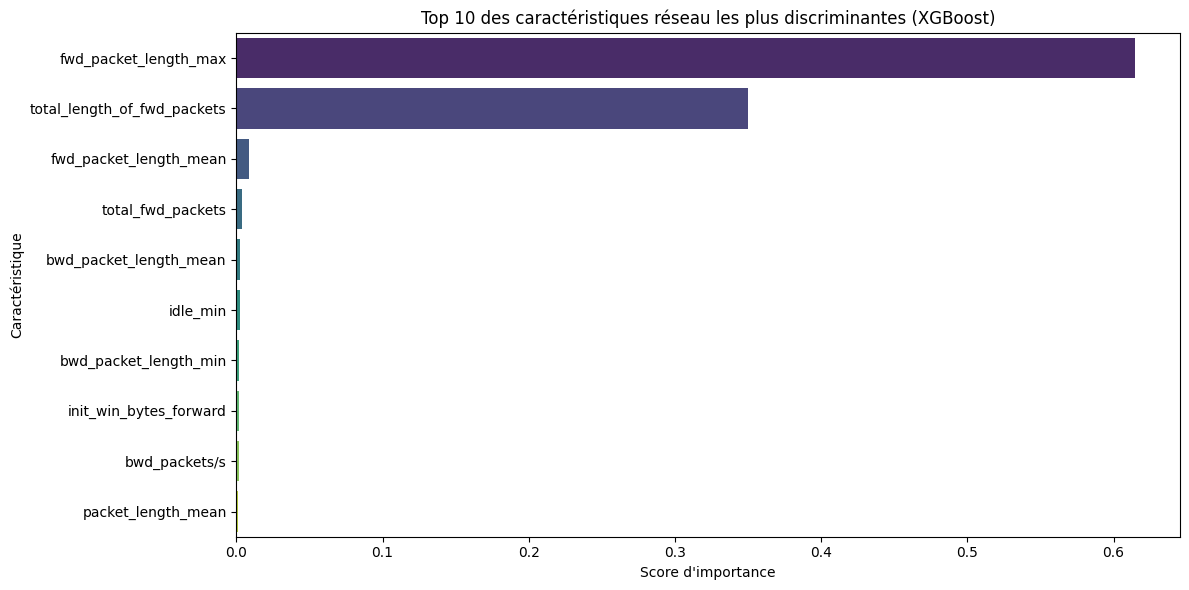

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("Calcul de l'importance des caractéristiques (Feature Importance)...")

# Récupération des scores d'importance du modèle XGBoost
importance = model_complet.feature_importances_
feature_names = X.columns
feat_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importance})

# Tri par ordre d'importance décroissant
feat_imp = feat_imp.sort_values(by='Importance', ascending=False)

# Création du graphique des 10 variables les plus impactantes
plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp.head(10), palette='viridis')
plt.title('Top 10 des caractéristiques réseau les plus discriminantes (XGBoost)')
plt.xlabel('Score d\'importance')
plt.ylabel('Caractéristique')
plt.tight_layout()

# Sauvegarde de l'image pour l'ajouter à tes slides de présentation
plt.savefig('feature_importance_ddos.png', dpi=300)
plt.show()

In [7]:
from google.colab import files

# Les 4 features de l'API FastAPI (maintenant en snake_case)
top_4_features = [
    'destination_port',
    'flow_duration',
    'total_fwd_packets',
    'total_backward_packets'
]

print(f"Sous-ensemble pour l'API : {top_4_features}")

X_train_light = X_train[top_4_features]
X_test_light = X_test[top_4_features]

# Entraînement du modèle de production (4 features)
model_production = xgb.XGBClassifier(
    n_estimators=50,
    learning_rate=0.1,
    max_depth=4,
    eval_metric='logloss'
)
model_production.fit(X_train_light, y_train)

# Évaluation
y_pred_light = model_production.predict(X_test_light)
print("\nPerformances du modèle de production (4 features) :")
print(classification_report(y_test, y_pred_light, target_names=le.classes_))

# Sauvegarde
model_production.save_model("NIDS_XGBoost_Production.json")
print("\n✅ Modèle sauvegardé !")

# ✅ TÉLÉCHARGEMENT AUTOMATIQUE
files.download("NIDS_XGBoost_Production.json")


Sous-ensemble pour l'API : ['destination_port', 'flow_duration', 'total_fwd_packets', 'total_backward_packets']

Performances du modèle de production (4 features) :
              precision    recall  f1-score   support

      BENIGN       1.00      0.98      0.99     29306
        DDoS       0.98      1.00      0.99     38408

    accuracy                           0.99     67714
   macro avg       0.99      0.99      0.99     67714
weighted avg       0.99      0.99      0.99     67714


✅ Modèle sauvegardé !


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
# Télécharger le graphique feature importance
files.download("feature_importance_ddos.png")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>